<a href="https://colab.research.google.com/github/anerocha/empregos-dados/blob/main/Untitled15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Análise de Vagas na Área de Dados (LinkedIn - Abril/2025)


## Contexto

O mercado de trabalho para profissionais da área de dados está em constante transformação e crescimento.  
Este projeto foi desenvolvido com base em um conjunto de dados extraído do LinkedIn e publicado no Kaggle, com informações de **vagas abertas em abril de 2025**.

A análise foca em compreender:

- Quais cargos são mais oferecidos (como Analista, Engenheiro e Cientista de Dados)
- Quais países estão contratando mais
- Quais empresas têm maior presença no mercado
- E, principalmente, **quais tecnologias e ferramentas são mais exigidas**

O objetivo é fornecer uma visão abrangente e atualizada do cenário de oportunidades para quem atua ou deseja atuar na área de dados.


## Introdução ao Projeto

Neste notebook, realizo uma análise exploratória de dados (EDA) sobre o mercado de trabalho em dados com base em vagas publicadas no LinkedIn.

O dataset analisado contém informações relevantes como:

- Título da vaga
- Nome da empresa
- Localização
- Descrição da vaga
- Data de publicação

As técnicas utilizadas incluem **limpeza e transformação de dados com Pandas**, **visualizações com Seaborn e Plotly** e **análise textual simples** para extração de *skills técnicas*.  
Além disso, parte da análise também foi comparada com resultados obtidos em **Power BI**, reforçando a multidisciplinaridade do projeto.

Esta análise serve tanto como um exercício prático de manipulação de dados quanto como uma fonte de insight sobre o cenário atual da área de dados.


##  1: Importação das Bibliotecas

Nesta etapa, importamos as bibliotecas essenciais para o projeto:

- `pandas`: manipulação e análise de dados
- `matplotlib.pyplot` e `seaborn`: visualizações gráficas estáticas
- `plotly.express`: gráficos interativos
- `google.colab.files` e `io`: upload de arquivos para o Colab

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files
import io


##  2: Upload e Leitura do Arquivo CSV

Realizamos o upload do arquivo `.csv` contendo os dados das vagas e lemos o conteúdo utilizando o `pandas`.


In [2]:
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded[next(iter(uploaded))]))


Saving clean_jobs.csv to clean_jobs.csv


##   3: Padronização dos Nomes das Colunas

Padronizamos os nomes das colunas do DataFrame para facilitar o manuseio e evitar erros de digitação.  
Transformações aplicadas:

- letras minúsculas
- remoção de espaços
- substituição de espaços por underscores (`_`)


In [3]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")


## 4: Conversão de Datas e Extração de Mês/Ano

Convertendo a coluna de datas (`date_posted`) para o formato `datetime`, extraímos também o campo `month_year` para facilitar análises temporais.


In [4]:
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
df['month_year'] = df['date_posted'].dt.to_period('M').astype(str)
df['month_year'] = pd.to_datetime(df['month_year'], format='%Y-%m')


##  5: Contagem de Palavras nas Descrições

Calculamos o número de palavras presentes em cada descrição de vaga, criando a coluna `description_word_count`.  
Esse dado pode indicar o nível de detalhamento das oportunidades.


In [5]:
df['description_word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))


##  6: Identificação do País

Com base na coluna `location`, classificamos se a vaga é do Brasil ou de outros países.  
Criamos a nova coluna `country` com os valores: `Brazil` ou `Other`.


In [6]:
df['country'] = df['location'].str.extract(r'(\bBrazil\b|\bBrasil\b)', expand=False).fillna('Other')


##  7: Classificação das Vagas por Categoria

Através do título da vaga (`title`), categorizamos os cargos em:

- Data Analyst
- Data Engineer
- Data Scientist
- BI Analyst
- ML Engineer
- Other

Utilizamos palavras-chave específicas para fazer essa classificação.


In [7]:
def classify_job(title):
    title = str(title).lower()
    if "data analyst" in title:
        return "Data Analyst"
    elif "data engineer" in title:
        return "Data Engineer"
    elif "data scientist" in title:
        return "Data Scientist"
    elif "bi analyst" in title:
        return "BI Analyst"
    elif "machine learning" in title or "ml engineer" in title:
        return "ML Engineer"
    else:
        return "Other"

df['job_category'] = df['title'].apply(classify_job)


##  8: Visualização das Categorias de Cargos

Criamos um gráfico de barras horizontal com as categorias de cargo mais frequentes.  
Objetivo: entender quais perfis estão sendo mais demandados no mercado.


<ipython-input-8-9ed53eb63e4b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='job_category', order=df['job_category'].value_counts().index, palette='crest')


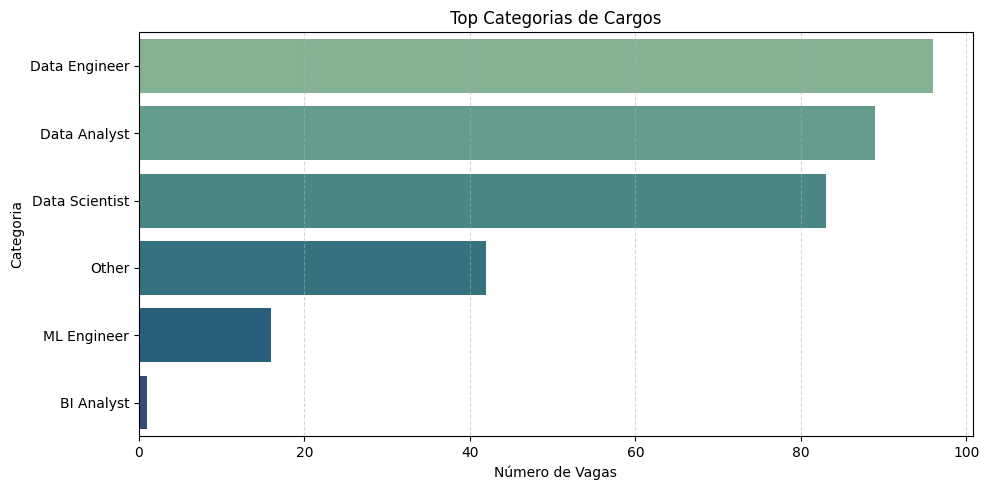

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='job_category', order=df['job_category'].value_counts().index, palette='crest')
plt.title('Top Categorias de Cargos')
plt.xlabel('Número de Vagas')
plt.ylabel('Categoria')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##  9: Distribuição das Vagas por País

Analisamos a proporção de vagas disponíveis no Brasil em comparação com o restante do mundo, usando um gráfico de barras simples.


<ipython-input-9-9c763a7040a0>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='country', order=['Brazil', 'Other'], palette='pastel')


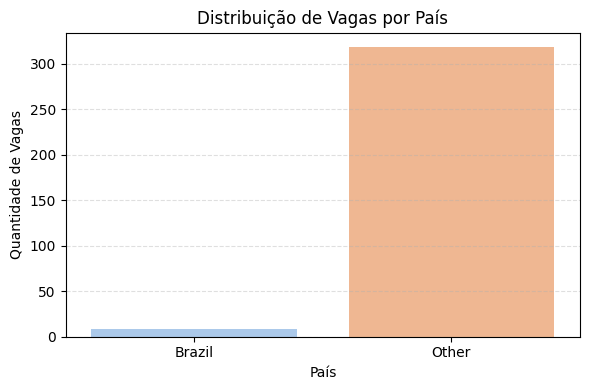

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='country', order=['Brazil', 'Other'], palette='pastel')
plt.title('Distribuição de Vagas por País')
plt.xlabel('País')
plt.ylabel('Quantidade de Vagas')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


##  10: Evolução Temporal das Vagas

Agrupamos as vagas por mês/ano de publicação e visualizamos a variação da quantidade de vagas ao longo do tempo usando um gráfico de linha.


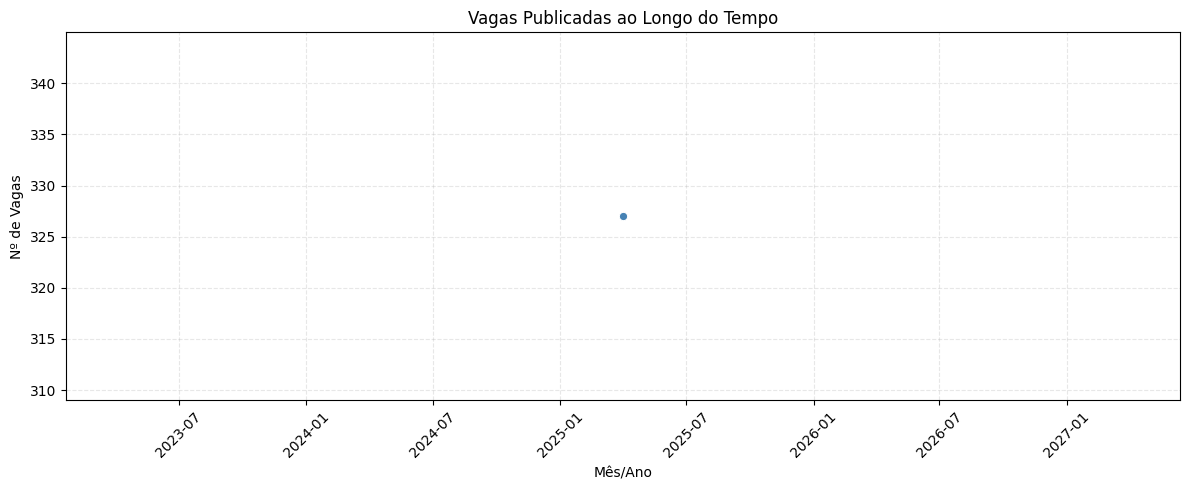

In [10]:
df_jobs_by_month = df.groupby('month_year').size().reset_index(name='job_count')
plt.figure(figsize=(12,5))
sns.lineplot(data=df_jobs_by_month, x='month_year', y='job_count', marker='o', linewidth=2.5, color='steelblue')
plt.title('Vagas Publicadas ao Longo do Tempo')
plt.xticks(rotation=45)
plt.ylabel('Nº de Vagas')
plt.xlabel('Mês/Ano')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 11: Top 10 Empresas com Mais Vagas

Identificamos as 10 empresas que mais publicaram vagas, visualizando o resultado com um gráfico de barras interativo do `Plotly`.


In [11]:
top_empresas = df['company'].value_counts().nlargest(10).reset_index()
top_empresas.columns = ['company', 'total_vagas']

fig = px.bar(
    top_empresas,
    x='total_vagas',
    y='company',
    orientation='h',
    title='Top 10 Empresas com Mais Vagas',
    labels={'total_vagas': 'Número de Vagas', 'company': 'Empresa'},
    color='total_vagas',
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()


## 12: Análise de Skills Técnicas mais Citadas

Realizamos uma contagem das principais *skills* técnicas mencionadas nas descrições das vagas:  
`Python`, `SQL`, `Excel`, `Power BI`, `AWS`, `Spark`, `R`, `Machine Learning`, `Deep Learning`.

Os resultados são exibidos em um gráfico de barras ordenado.


<ipython-input-12-9a815a3d24c1>:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




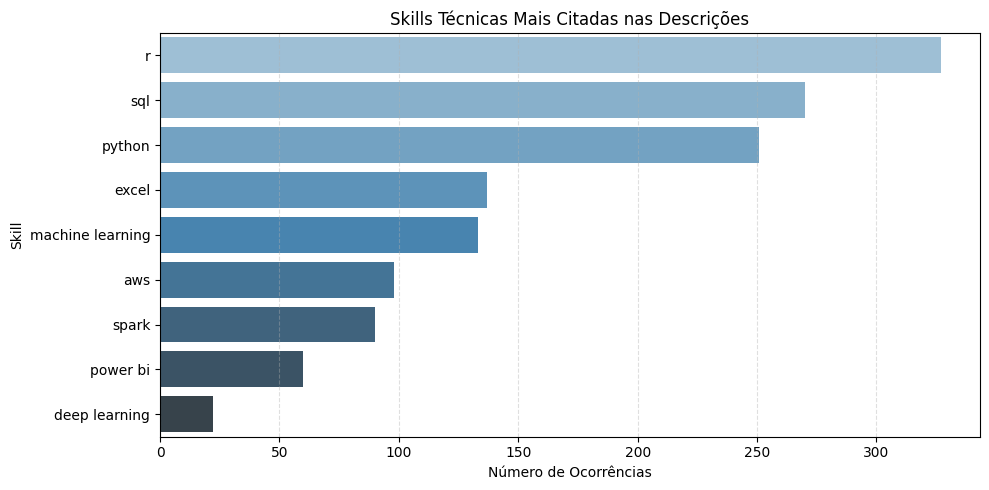

In [12]:
keywords = ['python', 'sql', 'excel', 'power bi', 'aws', 'spark', 'r', 'machine learning', 'deep learning']
skills = {key: df['description'].str.lower().str.contains(key).sum() for key in keywords}
skills_df = pd.DataFrame(list(skills.items()), columns=['skill', 'count']).sort_values(by='count', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=skills_df, x='count', y='skill', palette='Blues_d')
plt.title('Skills Técnicas Mais Citadas nas Descrições')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Skill')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Conclusão

A análise nos permitiu observar alguns pontos importantes sobre o mercado de dados em abril de 2025:

- **Data Analyst** é o cargo mais publicado, seguido por **Data Engineer** e **Data Scientist**
- O Brasil continua sendo um dos principais mercados, mas há ampla oferta global
- Empresas de grande porte lideram as publicações de vagas
- As *skills* técnicas mais requisitadas foram: **Python, SQL, Excel, Power BI, AWS e Machine Learning**

Este projeto também demonstrou como combinar Python e Power BI para enriquecer o processo de extração de insights.  
É mais um passo na jornada de me consolidar como profissional da área de dados, sempre buscando entender não apenas os dados, mas também o **contexto e as tendências do mercado**.

---

